## Data Dictionary

This dataset contains information about credit card customers and their payment behavior.

| Column | Description |
|------|-------------|
| ID | Unique identifier for each customer |
| LIMIT_BAL | Credit limit assigned to the customer (NT dollars) |
| SEX | Gender (1 = Male, 2 = Female) |
| EDUCATION | Education level (1 = Graduate School, 2 = University, 3 = High School, 4 = Others) |
| MARRIAGE | Marital status (1 = Married, 2 = Single, 3 = Others) |
| AGE | Age of the customer |
| PAY_0 | Repayment status in September 2005 |
| PAY_2 | Repayment status in August 2005 |
| PAY_3 | Repayment status in July 2005 |
| PAY_4 | Repayment status in June 2005 |
| PAY_5 | Repayment status in May 2005 |
| PAY_6 | Repayment status in April 2005 |
| BILL_AMT1 | Bill amount in September 2005 |
| BILL_AMT2 | Bill amount in August 2005 |
| BILL_AMT3 | Bill amount in July 2005 |
| BILL_AMT4 | Bill amount in June 2005 |
| BILL_AMT5 | Bill amount in May 2005 |
| BILL_AMT6 | Bill amount in April 2005 |
| PAY_AMT1 | Payment made in September 2005 |
| PAY_AMT2 | Payment made in August 2005 |
| PAY_AMT3 | Payment made in July 2005 |
| PAY_AMT4 | Payment made in June 2005 |
| PAY_AMT5 | Payment made in May 2005 |
| PAY_AMT6 | Payment made in April 2005 |
| default.payment.next.month | Indicates whether the customer defaulted next month (1 = Yes, 0 = No) |

### Payment Status Codes
- **-1** = Paid on time  
- **1** = Payment delayed by 1 month  
- **2** = Payment delayed by 2 months  
- **3+** = Payment delayed for multiple months

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") # Set the style for seaborn plots

In [14]:

# Load the dataset
df = pd.read_csv("UCI_Credit_Card.csv")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [15]:
df.shape

(30000, 25)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [17]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [18]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [19]:
#calcualte default payment rate
default_rate = df['default.payment.next.month'].mean()

print("Default Rate:", round(default_rate * 100, 2), "%")

Default Rate: 22.12 %


In [24]:
#payment delay analysis
df['PAY_0'].value_counts()

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

## Credit Limit Distribution
This chart shows how credit limits are distributed across customers.

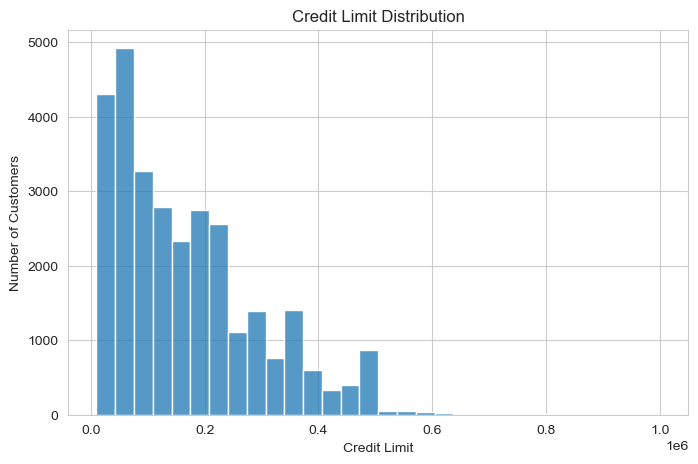

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['LIMIT_BAL'], bins=30)
plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")
plt.show()

## Default Rate by Gender
This analysis compares default rates across gender groups.

In [26]:
default_by_gender = df.groupby('SEX')['default.payment.next.month'].mean()
print(default_by_gender)

SEX
1    0.241672
2    0.207763
Name: default.payment.next.month, dtype: float64


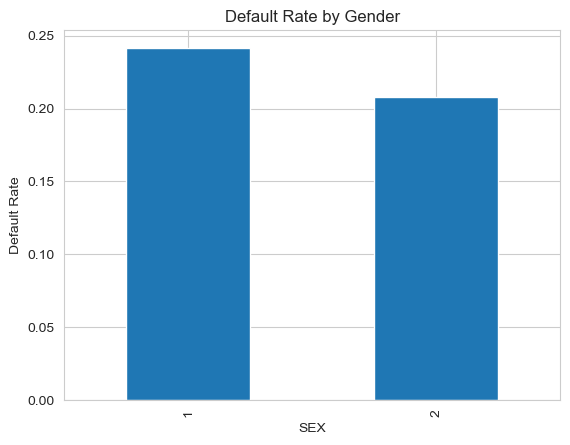

In [27]:
default_by_gender.plot(kind='bar')
plt.title("Default Rate by Gender")
plt.xlabel("SEX")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Age
This analysis examines how default rate changes with age.

AGE
21    0.208955
22    0.301786
23    0.265306
24    0.266193
25    0.254637
Name: default.payment.next.month, dtype: float64


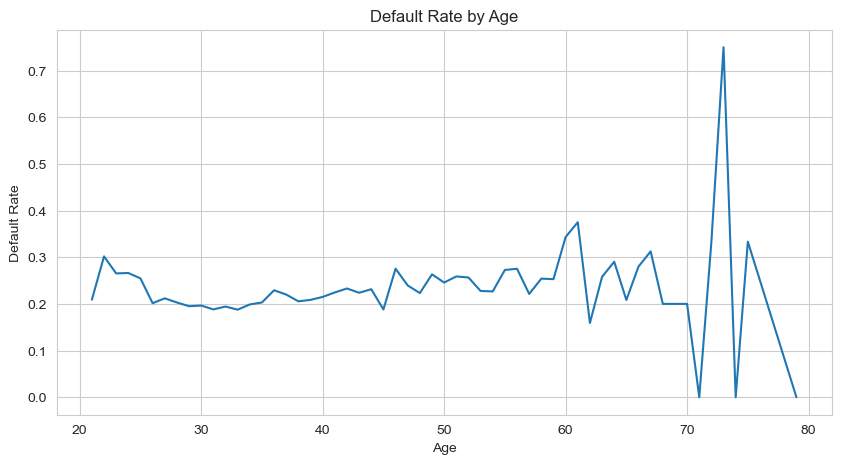

In [28]:
default_by_age = df.groupby('AGE')['default.payment.next.month'].mean()
print(default_by_age.head())

plt.figure(figsize=(10,5))
plt.plot(default_by_age.index, default_by_age.values)
plt.title("Default Rate by Age")
plt.xlabel("Age")
plt.ylabel("Default Rate")
plt.show()

## Bill Amount vs Payment Amount
This chart compares billed amount and payment amount for September 2005.

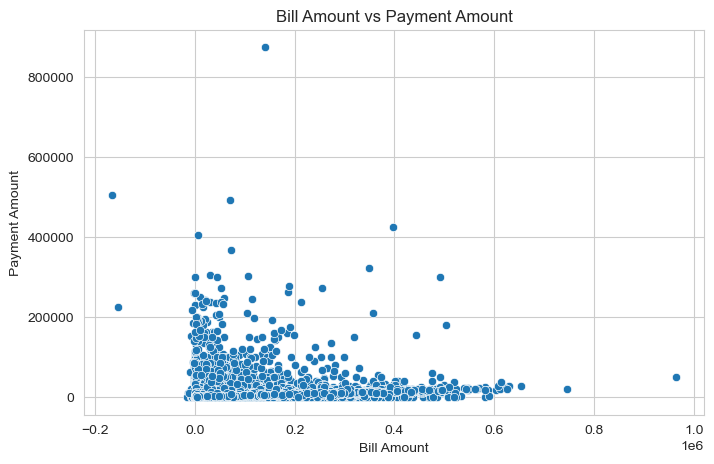

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['BILL_AMT1'], y=df['PAY_AMT1'])
plt.title("Bill Amount vs Payment Amount")
plt.xlabel("Bill Amount")
plt.ylabel("Payment Amount")
plt.show()

## Payment Delay Distribution
This chart shows the number of customers by repayment status in September 2005.

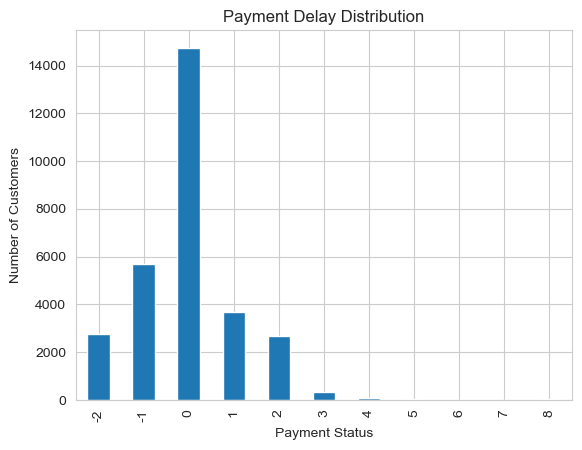

In [30]:
df['PAY_0'].value_counts().sort_index().plot(kind='bar')
plt.title("Payment Delay Distribution")
plt.xlabel("Payment Status")
plt.ylabel("Number of Customers")
plt.show()